In [1]:
%autosave 60
%pip install --quiet -r requirements.txt

Autosaving every 60 seconds
The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.
Note: you may need to restart the kernel to use updated packages.


## Setup

In [ ]:
import os
import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

from utils.mri.data_loader import DataLoader
from utils.mri.data_converter import DataConverter
from utils.analysis.data_analyser import DataAnalyser
from utils.metadata.combined_metadata_utils import CombinedMetadataUtils
from models.unet_3d_meta import META_Unet3D
from models.unet_3d_res import ResidualUNet3D
from utils.model_utils.train_eval import fit_feature_based_3D, fit_3D, get_metadata_features
from utils.model_utils.loss_functions import ssim_loss, l1_loss, ssim_l1_loss

root_path = "data/"

data_loader = DataLoader(root_path=root_path)
data_converter = DataConverter()
data_analyser = DataAnalyser(root_path=root_path)
metadata_loader = CombinedMetadataUtils()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Metadata features: F = {metadata_loader.n_features}")


Using device: cuda:0
Metadata features: F = 38


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


Flush cuda memory

In [3]:
torch.cuda.empty_cache()

Common Variables

In [4]:
model_epochs            = 1500
snapshot_every          = 500
model_checkpoint_every  = 250
n_meta_tokens           = 8

img_crop_axes = ((16, 10, 0), (17, 11, 17))


In [5]:
training_pairs, validation_pairs, test_pairs = data_loader.split_dataset_paths(seed=67)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")


We have 492 training pairs
We have 106 test pairs


## 3D META U-Net

### Model Training

In [ ]:
output_dir = "out/unets"
unet_path = f"{output_dir}/3d_unet_model_meta.pt"

# META-Unet now consumes (Hunt-3 volume, metadata) -> Hunt-4 volume.
# The model self-manages multi-GPU placement (dev0 / dev1) like FiLMUNet3D —
# do NOT call .to(device) on it.
unet = META_Unet3D(
    in_ch=1, out_ch=1, base=32, # Can be changed to 16
    cond_dim=metadata_loader.n_features,
    n_meta_tokens=8,
    residual=True,           # (recon, delta) head; delta is zero-inited so recon = x at iter 0
)

# Transformer-friendly LR + linear warmup + cosine decay.
# 2e-4 with AdamW(0.9, 0.95) blows up META's attention; 1e-4 with warmup is the standard transformer recipe.
unet_optimizer = optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-4, betas=(0.9, 0.999))

warmup_iters = 250
warmup     = optim.lr_scheduler.LinearLR(unet_optimizer, start_factor=1e-3, end_factor=1.0, total_iters=warmup_iters)
cosine     = optim.lr_scheduler.CosineAnnealingLR(unet_optimizer, T_max=max(model_epochs - warmup_iters, 1), eta_min=1e-6)
unet_scheduler = optim.lr_scheduler.SequentialLR(unet_optimizer, [warmup, cosine], milestones=[warmup_iters])


In [7]:
# Load existing model if it exists
if os.path.isfile(unet_path):
    print("Loading existing model")
    unet.load_state_dict(torch.load(unet_path))
else:
    print("No existing 3D U-Net found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)

No existing 3D U-Net found, starting fresh training.


In [8]:
unet, unet_losses, unet_snapshots, unet_best, best_val = fit_feature_based_3D(
    model=unet,
    device=device,
    training_pairs=training_pairs,
    validation_pairs=validation_pairs,
    epochs=model_epochs,
    loss_func=lambda p, t: ssim_l1_loss(p, t),
    metadata_loader=metadata_loader,
    dataConverter=data_converter,
    optimizer=unet_optimizer,
    scheduler=unet_scheduler,
    snapshot_every=snapshot_every,
    checkpoint_every=model_checkpoint_every,
    crop_axes=img_crop_axes,
)
print(f"Best val loss: {best_val:.6f}")


Training 3D U-Net with Features:   0%|          | 0/1500 [00:00<?, ?it/s]/home/ubuntu/NTNU-Master-project/utils/model_utils/train_eval.py:335: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1772176447874/work/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  if i % checkpoint_every == 0 and float(y_hat.abs().mean()) < 1e-4:
/home/conda/lib/python3.14/site-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Trai

Best val loss: 0.079355


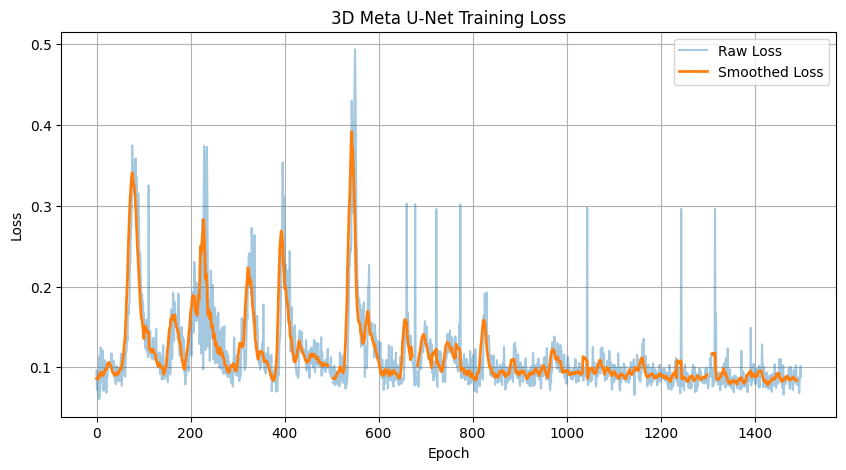

In [9]:
# Print unet losses
import matplotlib.pyplot as plt

def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_losses = moving_average(unet_losses, window_size=10)

plt.figure(figsize=(10, 5))
plt.plot(unet_losses, label='Raw Loss', alpha=0.4)
plt.plot(range(len(smoothed_losses)), smoothed_losses, label='Smoothed Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('3D Meta U-Net Training Loss')
plt.legend()
plt.grid()
plt.show()

Displaying snapshot from pair 500, loss: 0.0878


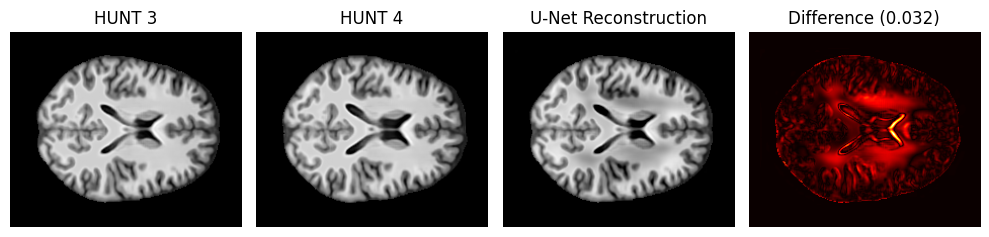

Displaying snapshot from pair 1000, loss: 0.0797


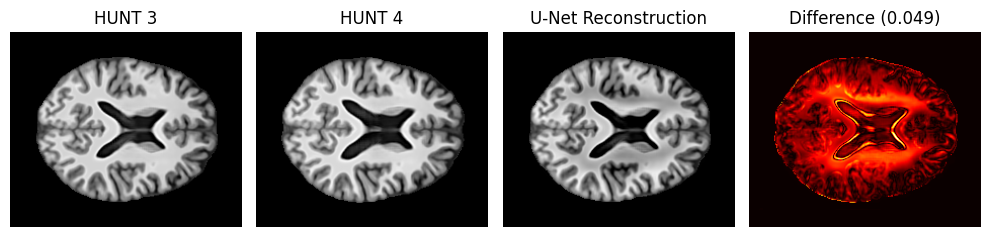

Displaying snapshot from pair 1499, loss: 0.0886


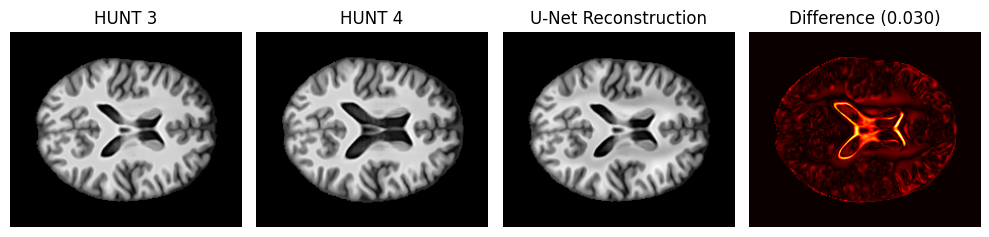

In [10]:
for snapshot in unet_snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}, loss: {snapshot['loss']:.4f}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_analyser.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "U-Net Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [ ]:
# Save the final model to the /out directory
torch.save(unet_best.state_dict(), unet_path)
print(f"Model saved to {unet_path}")

Model saved to out/unets/3d_unet_model_standard.pt


### Model Evaluation over Testset

In [ ]:
unet.eval()
avg_unet_loss = 0.0

with torch.no_grad():
    for (input_path, target_path) in tqdm(test_pairs):
        input_full  = data_converter.load_path_as_tensor(input_path)
        target_full = data_converter.load_path_as_tensor(target_path)
        input  = data_converter.get_volume_with_3d_change(tensor=input_full,  crop_axes=img_crop_axes, remove_mode=True)
        target = data_converter.get_volume_with_3d_change(tensor=target_full, crop_axes=img_crop_axes, remove_mode=True)

        cond = get_metadata_features(metadata_loader, input_path).unsqueeze(0)

        unet_recon, _ = unet(input, cond)
        avg_unet_loss += ssim_l1_loss(unet_recon, target.to(unet_recon.device)).item()

avg_unet_loss /= len(test_pairs)
print(f"Average META U-Net 3D Loss over Test Set: {avg_unet_loss:.4f}")

test_unet_path = f"{output_dir}/3d_unet_model_meta_testloss_{avg_unet_loss:.4f}.pt"
torch.save(unet.state_dict(), test_unet_path)
print(f"Test model saved to {test_unet_path}")


In [ ]:
unet.eval()
avg_unet_loss = 0.0

with torch.no_grad():
    for (input_path, target_path) in tqdm(test_pairs):
        input_full  = data_converter.load_path_as_tensor(input_path)
        target_full = data_converter.load_path_as_tensor(target_path)
        input  = data_converter.get_volume_with_3d_change(tensor=input_full,  crop_axes=img_crop_axes, remove_mode=True)
        target = data_converter.get_volume_with_3d_change(tensor=target_full, crop_axes=img_crop_axes, remove_mode=True)

        cond = get_metadata_features(metadata_loader, input_path).unsqueeze(0)

        unet_recon = unet(input, cond)
        avg_unet_loss += ssim_l1_loss(unet_recon, target.to(unet_recon.device)).item()

avg_unet_loss /= len(test_pairs)
print(f"Average META U-Net 3D Loss over Test Set: {avg_unet_loss:.4f}")

test_unet_path = f"{output_dir}/3d_unet_model_meta_testloss_{avg_unet_loss:.4f}.pt"
torch.save(unet.state_dict(), test_unet_path)
print(f"Test model saved to {test_unet_path}")


100%|██████████| 106/106 [01:09<00:00,  1.53it/s]

Average U-Net 3D Loss over Test Set: 0.0748
Test model saved to out/unets/3d_unet_model_standard_testloss_0.0748.pt


## Residual 3D U-Net

### Model Training

In [ ]:
output_dir = "out/unets"
unet_path = f"{output_dir}/3d_res_unet_model.pt"
unet = ResidualUNet3D(in_ch=1, base=32).to(device)
unet_optimizer = optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-4)

In [ ]:
# Load existing model if it exists
if os.path.isfile(unet_path):
    print("Loading existing model")
    unet.load_state_dict(torch.load(unet_path))
else:
    print("No existing Res U-Net found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)

No existing Res U-Net found, starting fresh training.


In [ ]:
unet, unet_losses, unet_snapshots, unet_best = fit_3D(
    model=unet,
    device=device,
    training_pairs=training_pairs,
    validation_pairs=validation_pairs,
    epochs=model_epochs,
    loss_func=ssim_loss,
    dataConverter=data_converter,
    optimizer=unet_optimizer,
    snapshot_every=snapshot_every,
    checkpoint_every=model_checkpoint_every,
    crop_axes=img_crop_axes,
)

Training 3D Residual U-Net:  17%|█▋        | 333/2000 [06:49<25:20,  1.10it/s, Best loss on val 0.224593, (Iter 250)]  

Training 3D Residual U-Net:  66%|██████▌   | 1322/2000 [25:20<10:36,  1.07it/s, Best loss on val 0.188613, (Iter 1250)]  

Displaying snapshot from pair 0, loss: 0.9823


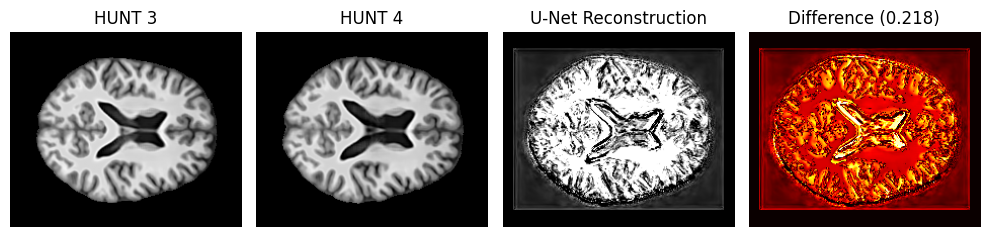

Displaying snapshot from pair 500, loss: 0.0913


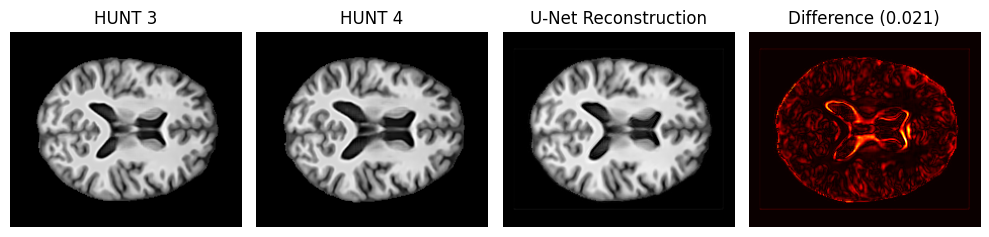

Displaying snapshot from pair 1000, loss: 0.0671


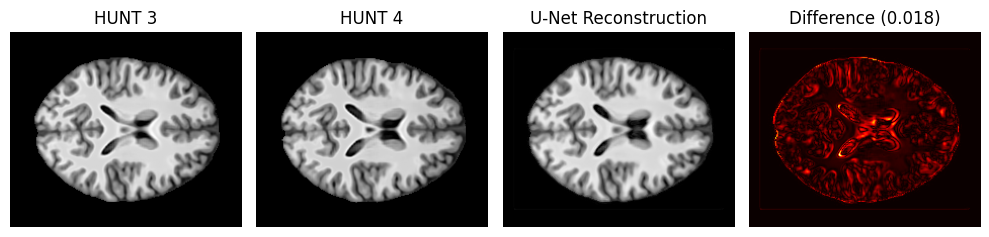

Displaying snapshot from pair 1500, loss: 0.0677


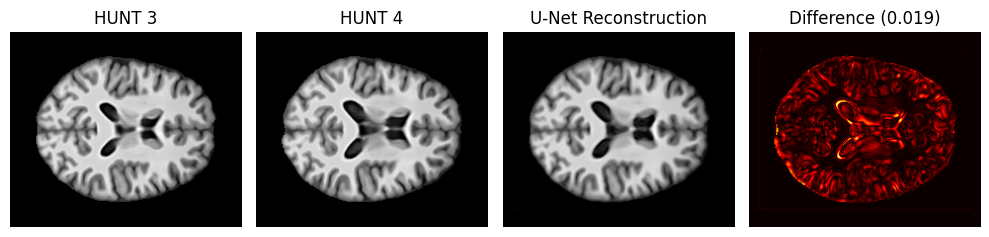

Displaying snapshot from pair 1999, loss: 0.0665


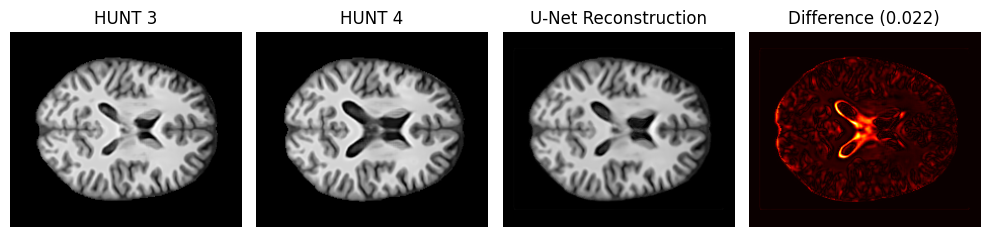

In [ ]:
for snapshot in unet_snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}, loss: {snapshot['loss']:.4f}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_analyser.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "U-Net Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [ ]:
# Save the final model to the /out directory
torch.save(unet_best.state_dict(), unet_path)
print(f"Model saved to {unet_path}")

Model saved to out/unets/3d_res_unet_model.pt


### Model Evaluation over Testset

In [ ]:
output_dir = "out/unets"
unet_path = f"{output_dir}/3d_res_unet_model.pt"

# Import model before testing
unet = ResidualUNet3D(in_ch=1, base=32).to(device)
unet.load_state_dict(torch.load(unet_path))
print("Loaded trained model for testing.")

Loaded trained model for testing.


In [ ]:
unet.eval()
avg_unet_loss = 0.0

# Estimate Accuracy over testset
for (input_path, target_path) in tqdm(test_pairs):
    # Import image from paths
    input_full, target_full = data_converter.load_path_as_tensor(input_path), data_converter.load_path_as_tensor(target_path)
    input, target = data_converter.get_volume_with_3d_change(tensor=input_full, crop_axes=img_crop_axes, remove_mode=True), data_converter.get_volume_with_3d_change(tensor=target_full, crop_axes=img_crop_axes, remove_mode=True)

    # Get Reconstructions
    unet_recon, _ = unet(input)
    target_num = target

    # calculate 3d loss
    avg_unet_loss += ssim_loss(unet_recon, target_num).item()

avg_unet_loss /= len(test_pairs)

print(f"Average U-Net 3D Loss over Test Set: {avg_unet_loss:.4f}")

# We save the model with the test loss in the filename for easy identification
test_unet_path = f"{output_dir}/3d_unet_model_standard_testloss_{avg_unet_loss:.4f}.pt"
torch.save(unet.state_dict(), test_unet_path)
print(f"Test model saved to {test_unet_path}")

  0%|          | 0/106 [00:00<?, ?it/s]

100%|██████████| 106/106 [00:52<00:00,  2.02it/s]


Average U-Net 3D Loss over Test Set: 0.0713
Test model saved to out/unets/3d_unet_model_standard_testloss_0.0713.pt
